# Part IV: Execution-Aware Replay (M6)

Converts the Part II out-of-sample surface forecasts into spread-aware trading
decisions and asks: **does the forecast retain positive vega-attributed markout
after observable spread costs, and does the edge survive round-trip and latency
sensitivities?** Markout here is vega-linearized throughout (contract IV change
times entry vega, minus spread costs), never option-premium P&L.

> "I treated this as a **decision-quality backtest**, not a claim of live
> tradability. The goal was to test whether the model improves quote adjustment /
> relative-value selection after conservative spread assumptions."

Design, endpoints, and falsifiable predictions were **pre-registered before any
replay computation** (qfdev_research `quant/forecasting/FINDINGS.md`, section
"PRE-REGISTRATION - M6", commit `613a309f`; Amendment 1 in `884ff426`).
All numbers below render from the saved outputs of the single full run.

Units: premium **dollars per share** (×100 for a standard contract).


In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Saved outputs of the single pre-registered run. The derived summary tables
# are committed in this repo under results/replay/ (preferred); the private
# research checkout is the fallback for the bulky per-trade extracts.
# Override with REPLAY_REPORTS.
PRIVATE = '../../qfdev_research/quant/forecasting/reports/replay'
R = os.environ.get('REPLAY_REPORTS') or next(
    d for d in ['../results/replay', PRIVATE] if os.path.isdir(d))
print('reading tables from:', R)
load = lambda name: pd.read_csv(os.path.join(R, name))
summary  = load('summary_main.csv')
boots    = load('bootstrap_cis.csv')
attr     = load('attribution_decomposition.csv')
regime   = load('summary_regime_15m.csv')
nonov    = load('summary_nonoverlap.csv')
unfill   = load('unfillable_report.csv')
delayed  = load('summary_delayed_entry.csv')
manifest = json.load(open(os.path.join(R, 'replay_manifest.json')))
print(f"run commit {manifest['git_commit'][:8]} · "
      f"{len(manifest['symbol_days'])} days · "
      f"preds sha256 {manifest['preds']['sha256'][:12]}…")

MODELS = ['ridge', 'lgbm', 'tcn']
COLOR  = {'ridge': '#2a78d6', 'lgbm': '#eb6834', 'tcn': '#1baf7a'}
pd.set_option('display.width', 160)


reading tables from: ../results/replay
run commit 884ff426 · 54 days · preds sha256 550ca70f8b7f…


## Headline: primary cells

Primary endpoint (pre-registered): pooled mean **entry-cost markout** per fillable
gated trade: ridge, 15 min, in-scope (DTE ≤ 7, |k| > 0.005), θ=1, λ=1, s=0, with a 95% day-bootstrap CI. The **round-trip touch net** (also paying the exit
half-spread) drives the economic verdict. Three denominators are always shown:
candidate decisions → gated attempts → fillable gated trades.


In [2]:
prim = summary[(summary.horizon_min == 15) & (summary.theta == 1.0)
               & (summary.slippage == 0.0) & (summary.lam_policy == 'raw')
               & (summary.scope == 'in_scope')]
cols = ['model', 'n_decisions', 'n_gated', 'n_fillable', 'pass_rate',
        'gross_mean', 'entry_cost_markout_mean', 'roundtrip_touch_net_mean',
        'hit_rate']
display(prim[cols].round(4))
display(boots[boots.horizon_min == 15].round(4))


,model,n_decisions,n_gated,n_fillable,pass_rate,gross_mean,entry_cost_markout_mean,roundtrip_touch_net_mean,hit_rate
108,ridge,721475,517882,509946,0.7178,0.0033,-0.0030,-0.0098,0.4157
144,lgbm,721475,403362,395509,0.5591,0.0034,-0.0028,-0.0095,0.4141
180,tcn,721475,432796,425799,0.5999,0.0037,-0.0027,-0.0097,0.4280


,horizon_min,model,theta,slippage,convention,mean,lo,hi,mean_eqday,n_days,n_trades
6,15,ridge,1.0,0.0,entry_cost_markout,-0.0030,-0.0040,-0.0021,-0.0029,54,509946
7,15,ridge,1.0,0.0,roundtrip_touch_net,-0.0098,-0.0108,-0.0088,-0.0096,54,509946
8,15,lgbm,1.0,0.0,entry_cost_markout,-0.0028,-0.0039,-0.0018,-0.0028,54,395509
9,15,lgbm,1.0,0.0,roundtrip_touch_net,-0.0095,-0.0107,-0.0084,-0.0093,54,395509
10,15,tcn,1.0,0.0,entry_cost_markout,-0.0027,-0.0042,-0.0014,-0.0023,54,425799
11,15,tcn,1.0,0.0,roundtrip_touch_net,-0.0097,-0.0115,-0.0080,-0.0090,54,425799


## Attribution decomposition (Amendment 1): is the cell signal tradable?

The pre-registered smoke fired gate G3: the tradable representative contract's
ΔIV is strongly attenuated versus the cell-median target the model predicts.
Decomposition separates membership churn (floating vs fixed-membership median)
from single-contract attenuation (fixed median vs contract).


In [3]:
a = attr[attr['slice'] == 'all']
display(a[['horizon_min', 'n', 'corr_y_fixed', 'corr_fixed_contract',
           'slope_contract_on_fixed', 'corr_y_contract',
           'std_y', 'std_fixed', 'std_contract']].round(3))
liq = attr[attr['slice'].str.startswith('liq_q')]
if len(liq):
    display(liq[['slice', 'n', 'corr_y_contract',
                 'slope_contract_on_fixed']].round(3))


,horizon_min,n,corr_y_fixed,corr_fixed_contract,slope_contract_on_fixed,corr_y_contract,std_y,std_fixed,std_contract
0,5,683118,0.737,0.277,0.094,0.126,0.017,0.013,0.004
1,15,659765,0.700,0.473,0.247,0.262,0.019,0.015,0.007
6,30,627917,0.696,0.639,0.436,0.409,0.021,0.017,0.011
7,60,567808,0.734,0.811,0.682,0.598,0.025,0.022,0.018


,slice,n,corr_y_contract,slope_contract_on_fixed
2,liq_q0,165160,0.750,0.685
3,liq_q1,167773,0.703,0.539
4,liq_q2,173308,0.377,0.321
5,liq_q3,153524,0.099,0.182


## Cost sensitivity: threshold θ and slippage

Gate: trade iff |vega·pred| > θ·half-spread + s. Conditional mean markout per
trade and pass rate across the pre-registered grids (15 min, in scope, λ=1).


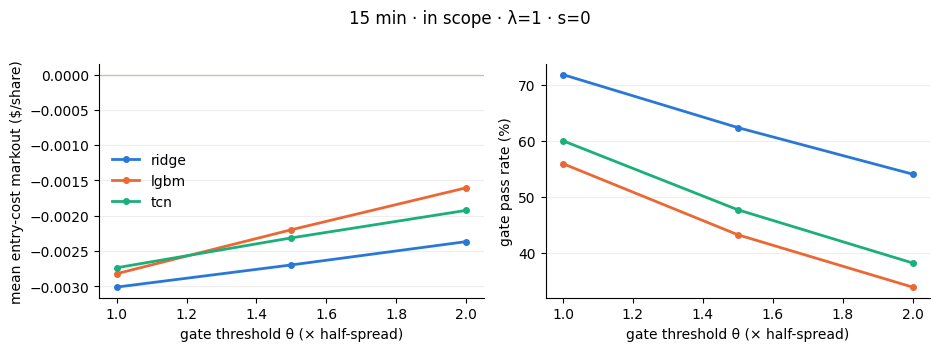

model,lgbm,ridge,tcn
slippage,,,
0.000,-0.0028,-0.0030,-0.0027
0.005,-0.0071,-0.0076,-0.0072
0.010,-0.0115,-0.0123,-0.0118


In [4]:
sens = summary[(summary.horizon_min == 15) & (summary.lam_policy == 'raw')
               & (summary.scope == 'in_scope') & (summary.slippage == 0.0)]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for m in MODELS:
    sm = sens[sens.model == m].sort_values('theta')
    axes[0].plot(sm.theta, sm.entry_cost_markout_mean, marker='o',
                 ms=4, lw=2, color=COLOR[m], label=m)
    axes[1].plot(sm.theta, 100 * sm.pass_rate, marker='o',
                 ms=4, lw=2, color=COLOR[m], label=m)
axes[0].axhline(0, color='#c3c2b7', lw=1)
axes[0].set_xlabel('gate threshold θ (× half-spread)')
axes[0].set_ylabel('mean entry-cost markout ($/share)')
axes[1].set_xlabel('gate threshold θ (× half-spread)')
axes[1].set_ylabel('gate pass rate (%)')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#eeeeec', lw=0.8)
axes[0].legend(frameon=False)
fig.suptitle('15 min · in scope · λ=1 · s=0', y=1.02)
fig.tight_layout()
plt.show()
slip = summary[(summary.horizon_min == 15) & (summary.lam_policy == 'raw')
               & (summary.scope == 'in_scope') & (summary.theta == 1.0)]
display(slip.pivot_table(index='slippage', columns='model',
        values='entry_cost_markout_mean').round(4))


## Regime breakdown (15 min, θ=1, in scope)


In [5]:
for axis in ('tod', 'dte_region', 'mny_region', 'liq_quartile'):
    t = regime[regime.axis == axis]
    if len(t):
        display(t.pivot_table(index='regime', columns='model',
                values='entry_cost_markout_mean', observed=True).round(4))


model,lgbm,ridge,tcn
regime,,,
close (330m+),-0.0045,-0.0020,-0.0028
midday (60-330m),-0.0024,-0.0032,-0.0028
open (0-60m),-0.0035,-0.0030,-0.0022


model,lgbm,ridge,tcn
regime,,,
short (1-7),-0.0028,-0.003,-0.0027


model,lgbm,ridge,tcn
regime,,,
far-wing (>.025),-0.0042,-0.0046,-0.0037
near-wing (.005-.025),-0.0020,-0.0022,-0.0022


model,lgbm,ridge,tcn
regime,,,
0.0,-0.0035,-0.0036,-0.0037
1.0,-0.0015,-0.0019,-0.0016
2.0,-0.0026,-0.0028,-0.0021
3.0,-0.0037,-0.0039,-0.0036


## Non-overlapping variant and concurrency

Greedy per-cell cooldown (= horizon). The cumulative series is **one-contract
non-overlapping edge**, *not* a capitalized portfolio equity curve; concurrency
diagnostics quantify how overlapped the naive per-minute decisions are.


,horizon_min,model,n_trades_overlapping,n_trades_nonoverlap,count_ratio,mean_entry_markout_overlap,mean_entry_markout_nonoverlap,mean_roundtrip_nonoverlap,cum_entry_markout_nonoverlap,max_concurrent,mean_concurrent,max_gross_vega,n_active_cells
0,5,ridge,464798,122343,0.2632,-0.0058,-0.0058,-0.0125,-714.6387,55,32.3943,810.1542,2002
1,5,lgbm,310099,101015,0.3258,-0.0050,-0.0054,-0.0119,-546.0557,55,27.1813,649.5304,2003
2,5,tcn,341640,107049,0.3133,-0.0055,-0.0057,-0.0123,-605.9301,57,28.8109,753.4280,2002
3,15,ridge,509946,44080,0.0864,-0.0030,-0.0038,-0.0104,-168.2170,57,34.5801,832.5557,2000
4,15,lgbm,395509,41928,0.1060,-0.0028,-0.0039,-0.0105,-161.9822,57,32.8554,679.9072,1999
5,15,tcn,425799,42464,0.0997,-0.0027,-0.0036,-0.0102,-151.1791,56,33.3711,705.6098,2001
6,30,ridge,530985,22297,0.0420,0.0009,0.0000,-0.0066,0.7088,56,34.1459,781.1568,1996
7,30,lgbm,454580,21900,0.0482,0.0010,-0.0004,-0.0070,-9.1247,57,33.3530,662.0340,1995
8,30,tcn,457307,21921,0.0479,0.0025,0.0012,-0.0055,25.7424,58,33.4652,650.8361,1996
9,60,ridge,517685,11131,0.0215,0.0083,0.0077,0.0010,85.6700,58,32.8214,806.2509,1992


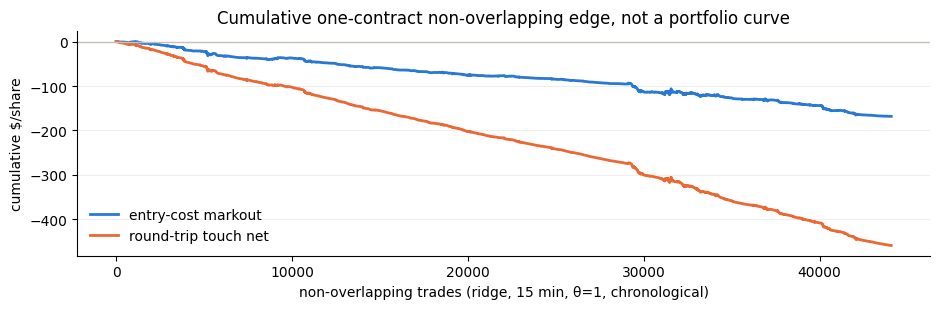

In [6]:
display(nonov.round(4))
# Cumulative curve from the per-trade artifact when available (optional).
# The per-trade parquet (~850 MB) is not committed; this renders only where
# the private research checkout is present.
tdir = next((os.path.join(d, 'trades') for d in [R, PRIVATE]
             if os.path.isdir(os.path.join(d, 'trades'))), 'trades-missing')
if os.path.isdir(tdir):
    frames = []
    for f in sorted(os.listdir(tdir)):
        d = pd.read_parquet(os.path.join(tdir, f))
        d = d[(d.horizon_min == 15) & d.in_scope
              & d.match_reason.eq('matched') & ~d.unfillable_exit
              & d.iv_tH.notna()]
        d = d[(d.vega_t * d.pred_ridge).abs() > d.half_spread_t]
        frames.append(d[['symbol_day', 'minute', 'dte_bucket',
                         'moneyness_bucket', 'gross_vega_linear_ridge',
                         'half_spread_t', 'half_spread_tH']])
    tr = pd.concat(frames, ignore_index=True).sort_values('minute')
    keep, last = [], {}
    for r in tr.itertuples():
        c = (r.symbol_day, r.dte_bucket, r.moneyness_bucket)
        ok = c not in last or (pd.Timestamp(r.minute) - last[c]
                               >= pd.Timedelta(minutes=15))
        keep.append(ok)
        if ok:
            last[c] = pd.Timestamp(r.minute)
    no = tr[np.array(keep)].copy()
    no['ecm'] = no.gross_vega_linear_ridge - no.half_spread_t
    no['rtn'] = no.ecm - no.half_spread_tH
    fig, ax = plt.subplots(figsize=(9.5, 3.2))
    x = np.arange(len(no))
    ax.plot(x, no.ecm.cumsum(), lw=2, color='#2a78d6',
            label='entry-cost markout')
    ax.plot(x, no.rtn.cumsum(), lw=2, color='#eb6834',
            label='round-trip touch net')
    ax.axhline(0, color='#c3c2b7', lw=1)
    ax.set_xlabel('non-overlapping trades (ridge, 15 min, θ=1, chronological)')
    ax.set_ylabel('cumulative $/share')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#eeeeec', lw=0.8)
    ax.legend(frameon=False)
    ax.set_title('Cumulative one-contract non-overlapping edge, '
                 'not a portfolio curve')
    fig.tight_layout()
    plt.show()
else:
    print('trades/ artifact not present; table only')


## Honesty diagnostics

Exit fillability (validity condition: gated unfillability < 5% and not
concentrated in the largest predicted edges) and the 1-minute delayed-entry
latency arm (same instrument chosen at t, entry at its t+1 touch).


In [7]:
display(unfill[unfill.theta == 1.0].round(4))
display(delayed.round(4))


,horizon_min,model,theta,n_decisions,n_matched,n_gated,n_unfillable,unfillable_rate
0,5,ridge,1.0,741221,688678,468506,3708,0.0079
3,5,lgbm,1.0,741221,688678,313571,3472,0.0111
6,5,tcn,1.0,741221,688678,344786,3146,0.0091
9,15,ridge,1.0,721475,671146,517882,7936,0.0153
12,15,lgbm,1.0,721475,671146,403362,7853,0.0195
15,15,tcn,1.0,721475,671146,432796,6997,0.0162
18,30,ridge,1.0,691678,644590,543251,12266,0.0226
21,30,lgbm,1.0,691678,644590,466962,12382,0.0265
24,30,tcn,1.0,691678,644590,468118,10811,0.0231
27,60,ridge,1.0,630908,589900,535600,17915,0.0334


,horizon_min,model,n_trades,entry_t1_available_rate,mean_entry_markout_immediate,mean_entry_markout_delayed
0,5,ridge,464521,0.9994,-0.0058,-0.0063
1,5,lgbm,309854,0.9992,-0.0050,-0.0057
2,5,tcn,341419,0.9994,-0.0055,-0.0063
3,15,ridge,509566,0.9993,-0.0030,-0.0036
4,15,lgbm,395148,0.9991,-0.0028,-0.0035
5,15,tcn,425484,0.9993,-0.0027,-0.0035
6,30,ridge,530695,0.9995,0.0009,0.0003
7,30,lgbm,454294,0.9994,0.0010,0.0003
8,30,tcn,457048,0.9994,0.0025,0.0018
9,60,ridge,517450,0.9995,0.0083,0.0078


## Verdict vs the pre-registered predictions

Adjudicated against the pre-registration + Amendment 1 exactly as written
(single full run, 54 test days, code @ `884ff426`; the authoritative version
is the "ADJUDICATION - M6" section of `FINDINGS.md`).

**Gates.** G1 (self-test + lookahead probes) **PASS**. G2 (unmatched < 2%)
**marginal breach, disclosed**: 2.4–2.6% per horizon, 100% of it
`no_otm_side`: far-wing cells whose node never contained a valid OTM-side
contract, i.e. cells the replay's tradable instrument is not defined on.
Validity condition **PASS** both clauses: gated exit unfillability 1.53% < 5%
and *decreasing* in |predicted edge| (top decile 0.37%).

**Primary endpoint: NEGATIVE.** Ridge, 15 min, in scope, θ=1, λ=1, s=0:
mean entry-cost markout **−\$0.0030** per fillable trade, 95% day-bootstrap
CI **[−0.0040, −0.0021]** (509,946 trades, 54/54 days); round-trip touch net
−\$0.0098 [−0.0108, −0.0088]. Per the pre-registered decision rule:
**15-minute surface forecasts of this quality do not clear the touch.**

| Prediction | Verdict | What happened |
|---|---|---|
| R1: pass rate ∈ [2, 30]% | **REJECTED** | 71.8%: the gate believes the cell-median move (std ≈ 0.019 vol) that the tradable contract does not realize (slope ≈ 0.25 at 15m) |
| R2: gross selection works | **SUPPORTED** | conditional gross edge +0.0033 (θ=1) → +0.0040 (θ=2), positive and monotone for all three models; the failure is cost-sized, not signal-sized |
| R3: markout survives entry cost | **REJECTED** | primary ≤ 0 (round-trip band [−0.05, +0.01] was met at −0.0098, but the rule keys on the primary) |
| R4: LGBM over-trades & underperforms | **REJECTED** | LGBM pass rate 55.9% < ridge 71.8%, per-trade −0.0028 ≥ ridge −0.0030; walk-forward λ changes ≤ 0.0003 |
| R5: out-of-scope worse | **SUPPORTED** | ridge out-of-scope conditional gross +0.0023 < in-scope +0.0033, markout −0.0112 |
| R6: non-overlap preserves the story | **SUPPORTED** | count ratio 0.086 ∈ [1/15, 1/3], signs unchanged (−0.0030 → −0.0038) |

**The finding (Amendment 1 decomposition).** Membership churn is a roughly
constant haircut (corr(y, fixed) ≈ 0.7 at every horizon); the
horizon-dependent attenuation is per-contract. At 5–15 min the cell-median
ΔIV the model forecasts is mostly quote-bounce of the cell's wide members: mean-reverting and *predictable*, but not realizable on the tradable tight
contract (slope 0.09 at 5m, 0.25 at 15m). By 60 min the contract genuinely
realizes ~0.7 of the cell move.

**Exploratory (multiple-comparison caveat; the primary was 15m).** The
economics improve monotonically with horizon exactly as the decomposition
predicts: entry-cost markout −0.0058 (5m) → −0.0030 (15m) → +0.0009 (30m,
CI straddles 0) → **+0.0083 (60m, CI [+0.0043, +0.0117] entirely
positive)**; 60m round-trip +0.0015 (breakeven). The 60m result survives the
1-minute delayed-entry arm (+0.0078) and non-overlap sampling (+0.0077).
This names the next pre-registerable hypothesis; it is not a claimed win.

> Part IV did exactly what it was built to do: it separated forecast skill
> from decision value and located where each lives. The forecast is real
> (R2) and correctly scoped (R5), but at the 15-minute story horizon it
> prices cell-median dislocations the tradable contract never delivers; at
> 60 minutes the same forecasts clear the entry cost decisively and break
> even round-trip.
